In [37]:
import glob
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.interpolate import RegularGridInterpolator

In [38]:
root = "../SinglePBH"
pattern = os.path.join(root, "PBH_M*_N*", "rho0*.csv")
paths = sorted(glob.glob(pattern))

dir_re = re.compile(r"PBH_M([\d.eE+-]+)_N([\d.eE+-]+)")
file_re = re.compile(r"rho0([\d.eE+-]+)\.csv$")

In [60]:
records = []  # list of (M, N, rho, surface_temperature)
for path in paths:
	dirname = os.path.basename(os.path.dirname(path))
	filename = os.path.basename(path)

	dir_match = dir_re.search(dirname)
	file_match = file_re.search(filename)
	if not dir_match or not file_match:
		print(f"WARNING: could not parse M/N/rho from '{path}', skipping")
		continue
	M = float(dir_match.group(1))
	N = float(dir_match.group(2))
	rho = float(file_match.group(1))

	df = pd.read_csv(path)
	if df.empty:
		print(f"WARNING: '{path}' is empty, skipping")
		continue
	surface_row = df.loc[df["radius"].idxmax()]  
	T_surface = surface_row["temperature"]
	
	core_row = df.loc[df["radius"].idxmin()]  
	T_core = core_row["temperature"]

	records.append((M, N, rho, T_surface, T_core))

df_all = pd.DataFrame(records, columns=["M", "N", "rho", "T_surface", "T_core"])

In [80]:
def plot_heatmap(fig, ax, rho_values, N_values, temp, sub,
                 xlabel="Number of PBH ($N$)",
                 ylabel=r"Center Density ($\rho$) [g/cc]",
                 xlimit=None,
                 cbar_label="Surface temperature [K]",
                 scatter=False):
    T_grid = np.full((len(rho_values), len(N_values)), np.nan)
    for _, row in sub.iterrows():
        i = np.searchsorted(rho_values, row["rho"])
        j = np.searchsorted(N_values, row["N"])
        T_grid[i, j] = row[temp]

    nan_mask = np.isnan(T_grid)
    if nan_mask.any():
        print(f"WARNING: M={M:.1e} has {nan_mask.sum()}/{T_grid.size} missing grid points, filling via nearest-neighbour before interpolating")
        from scipy.interpolate import griddata
        ii, jj = np.meshgrid(np.arange(len(rho_values)), np.arange(len(N_values)), indexing="ij")
        valid = ~nan_mask
        T_grid[nan_mask] = griddata(
            points=np.column_stack([ii[valid], jj[valid]]),
            values=T_grid[valid],
            xi=np.column_stack([ii[nan_mask], jj[nan_mask]]),
            method="cubic",
        )

    n_fine = 200  # resolution of the interpolated grid along each axis

    log_rho = np.log10(rho_values)
    log_N = np.log10(N_values)
    log_T = np.log10(T_grid)

    interp = RegularGridInterpolator((log_rho, log_N), log_T, method="linear", bounds_error=False, fill_value=None)

    N_fine = np.logspace(log_N.min(), log_N.max(), n_fine)
    rho_fine = np.logspace(log_rho.min(), log_rho.max(), n_fine)
    rho_fine_grid, N_fine_grid = np.meshgrid(rho_fine, N_fine, indexing="ij")

    query_points = np.column_stack([np.log10(rho_fine_grid).ravel(), np.log10(N_fine_grid).ravel()])
    T_fine = 10.**interp(query_points).reshape(rho_fine_grid.shape)

    valid = T_grid[~np.isnan(T_grid)]
    norm = LogNorm(vmin=valid.min(), vmax=valid.max()) if valid.size and valid.min() > 0 else None

    mesh = ax.pcolormesh(N_fine, rho_fine, T_fine, shading="auto", norm=norm, rasterized=True)
    
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    
    if xlimit is not None:
        ax.set_xlim(xlimit[0], xlimit[1])

    N_grid_pts, rho_grid_pts = np.meshgrid(N_values, rho_values)
    if scatter:
        ax.scatter(N_grid_pts, rho_grid_pts, c="white", s=10, edgecolors="k", linewidths=0.5, zorder=3)

    cbar = fig.colorbar(mesh, ax=ax)
    cbar.set_label(cbar_label)

    return ax

Saved ../img/temp_heatmap_5.0e+14.pgf


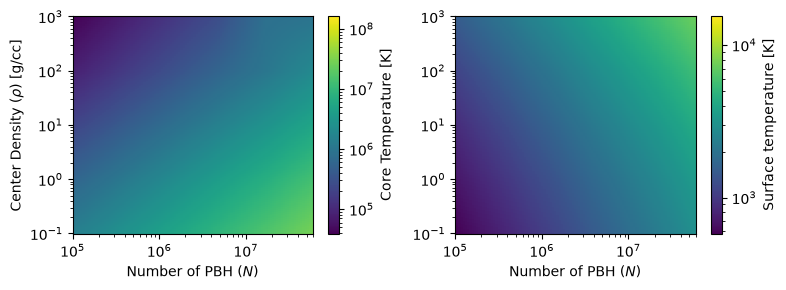

In [83]:
for M in sorted(df_all["M"].unique()[1:2]):
	sub = df_all[df_all["M"] == M]

	N_values = np.sort(sub["N"].unique())
	rho_values = np.sort(sub["rho"].unique())

	fig, ax = plt.subplots(1, 2, figsize=(8, 3))
	
	plot_heatmap(fig, ax[0], rho_values, N_values, "T_core", sub, xlimit=(1e5, 6e7), cbar_label="Core Temperature [K]",)
	plot_heatmap(fig, ax[1], rho_values, N_values, "T_surface", sub, xlimit=(1e5, 6e7), ylabel="")
	
	plt.tight_layout()
	out_name = f"../img/temp_heatmap_{M:.1e}.pgf"
	plt.savefig(out_name)
	print(f"Saved {out_name}")